<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [4]:

# 1. Download stock data
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN"]
data = yf.download(stocks, start="2020-01-01", end="2025-08-15")["Close"]

/tmp/ipython-input-3930836619.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2020-01-01", end="2025-08-15")["Close"]
[*********************100%***********************]  4 of 4 completed


In [5]:
# 2. Calculate log returns
returns = np.log(data / data.shift(1)).dropna()

In [6]:
# 3. Mean and covariance
mean_returns = returns.mean()
cov_matrix = returns.cov()

In [7]:
# 4. Portfolio performance function
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.dot(weights, mean_returns) * 252  # annualized return
    risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))
    return risk, returns

In [8]:
# 4. Portfolio performance function
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.dot(weights, mean_returns) * 252  # annualized return
    risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))
    return risk, returns

In [12]:
# 5. Negative Sharpe ratio (to maximize Sharpe)
def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    risk, ret = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - risk_free_rate) / risk

In [11]:
# 6. Constraints (weights sum to 1)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for asset in range(len(stocks)))

In [13]:
# 7. Initial guess
init_guess = len(stocks) * [1. / len(stocks)]

# 8. Optimization
opt_results = minimize(neg_sharpe_ratio, init_guess,
                       args=(mean_returns, cov_matrix),
                       method='SLSQP', bounds=bounds, constraints=constraints)

# Optimal weights
optimal_weights = opt_results.x
print("Optimal Portfolio Weights:", dict(zip(stocks, optimal_weights)))

Optimal Portfolio Weights: {'AAPL': np.float64(0.2597184379147444), 'MSFT': np.float64(0.0), 'GOOGL': np.float64(0.09598498438480288), 'AMZN': np.float64(0.6442965777004527)}


In [14]:
# 9. Generate Efficient Frontier
def efficient_frontier(mean_returns, cov_matrix, returns_range):
    target_returns = np.linspace(returns_range[0], returns_range[1], 50)
    risks = []
    rets = []
    for r in target_returns:
        constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
                       {'type': 'eq', 'fun': lambda x: portfolio_performance(x, mean_returns, cov_matrix)[1] - r})
        result = minimize(lambda w: portfolio_performance(w, mean_returns, cov_matrix)[0],
                          init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        if result.success:
            risks.append(result.fun)
            rets.append(r)
    return risks, rets

risks, rets = efficient_frontier(mean_returns, cov_matrix, (0.1, 0.3))


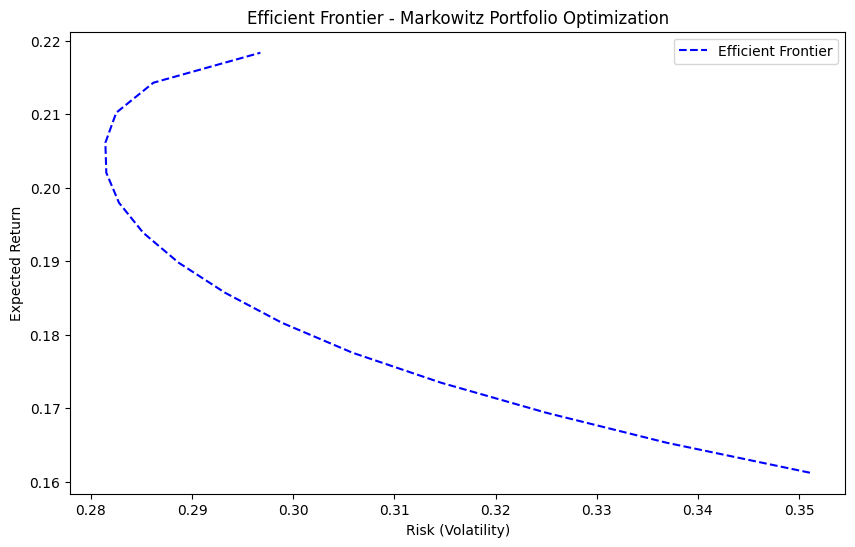

In [15]:

# 10. Plot Efficient Frontier
plt.figure(figsize=(10,6))
plt.plot(risks, rets, 'b--', label='Efficient Frontier')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier - Markowitz Portfolio Optimization')
plt.legend()
plt.show()